# 연고관광 도메인별 클러스터 lift

## 분석 목적과 범위

기존 전체변수 클러스터 lift 결과 중 해석 가능한 특징을 도메인별로 다시
정리한다. 각 도메인에서 층별로 차이가 큰 특징을 선정하고, 같은 특징의
모든 군집 값을 함께 제시해 군집 프로필을 비교한다.

- 입력은 기존 노트북이 저장한 `cluster_lift_all_variables.csv` 한 파일이다.
  원자료·군집 라벨링 자료·모형은 다시 불러오거나 재계산하지 않는다.
- 방문 동기와 여행지 선택 이유는 `여행 행태·구조` 도메인에 포함한다.
- 색과 셀 숫자는 모두 `log2(lift)`다. 0은 같은 층 평균, 양수는 과대표,
  음수는 과소대표를 뜻한다.
- lift는 군집 특성의 상대 비교이며 인과효과가 아니다.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").is_dir():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError("src 폴더가 있는 프로젝트 루트를 찾지 못했습니다.")
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from textwrap import fill

from src.path import OUTPUTS_DIR, create_output_directories
from src.visualization import COLORS, apply_plot_style

apply_plot_style()

NOTEBOOK_NAME = "260726_연고관광_도메인별_클러스터_lift.ipynb"
SOURCE_OUTPUT_NAME = "260726_연고관광_전체변수_클러스터_lift_260726_0745"
SOURCE_TABLE_PATH = (
    OUTPUTS_DIR
    / SOURCE_OUTPUT_NAME
    / "tables"
    / "cluster_lift_all_variables.csv"
)
FIGURES_DIR, TABLES_DIR = create_output_directories(NOTEBOOK_NAME)

STRATUM_COLUMN = "층"
CLUSTER_COLUMN = "군집"
DOMAIN_COLUMN = "도메인"
MIN_CLUSTER_N = 30
MIN_BASE_SHARE = 0.01
TOP_FEATURES_PER_DOMAIN = 12
COLOR_LIMIT = 3.0
FEATURE_LABEL_WRAP_WIDTH = 28
DOMAIN_ORDER = [
    "여행 행태·구조",
    "활동·경험",
    "지출·소비구성",
    "정보·예약·상품",
    "인구사회학",
    "여행 평가·영향",
]

VISUAL_RANKED_PREFIXES = ("A3", "A5", "A5A", "D_TRA_B7", "ZQ1")
VISUAL_EXCLUDED_VARIABLES = {
    "BARA",
    "primary_transport",
    "car_dependence",
    "public_transport",
    *{
        f"{prefix}_{rank}"
        for prefix in VISUAL_RANKED_PREFIXES
        for rank in range(2, 4)
    },
}
VISUAL_EXCLUDED_PREFIXES = ("NA8F",)
INTERPRETATION_EXCLUDED_LEVELS = {
    "A4A": {"21"},
    **{
        f"A9A_{question_no}": {"9"}
        for question_no in range(1, 13)
    },
}

In [2]:
lift_all = pd.read_csv(SOURCE_TABLE_PATH, encoding="utf-8-sig")

required_columns = {
    STRATUM_COLUMN,
    CLUSTER_COLUMN,
    "변수",
    "변수 라벨",
    "변수 유형",
    "표시 특징",
    "군집 셀 비가중 N",
    "층 내 가중 비율",
    "실질 수준 여부",
    "log2(lift)",
}
missing_columns = required_columns - set(lift_all.columns)
assert not missing_columns, f"입력 결과표에 없는 열: {sorted(missing_columns)}"

print(f"입력 표: {SOURCE_TABLE_PATH}")
print(f"전체 lift 행: {len(lift_all):,}")
display(lift_all.head(3))

입력 표: C:\Users\ilove\OneDrive\Desktop\tourism_poster\outputs\260726_연고관광_전체변수_클러스터_lift_260726_0745\tables\cluster_lift_all_variables.csv
전체 lift 행: 4,136


,층,군집,변수 유형,변수,변수 라벨,수준 코드,수준 라벨,표시 특징,군집 셀 비가중 N,유효 비가중 N,...,결측 N,가중 분모,군집값,층 기준값,가중평균 차이,층 내 가중 비율,lift,log2(lift),lift 미산출 사유,실질 수준 여부
0,당일여행,당일여행 C1,범주형,YEAR,조사연도,2023,2023년,조사연도 — 2023: 2023년,677,677,...,0,6.700951e+06,0.348531,0.363849,-0.015318,0.363849,0.957901,-0.062052,NaN,True
1,당일여행,당일여행 C1,범주형,YEAR,조사연도,2024,2024년,조사연도 — 2024: 2024년,677,677,...,0,6.700951e+06,0.410655,0.387997,0.022658,0.387997,1.058398,0.081882,NaN,True
2,당일여행,당일여행 C1,범주형,YEAR,조사연도,2025,2025년,조사연도 — 2025: 2025년,677,677,...,0,6.700951e+06,0.240814,0.248154,-0.007340,0.248154,0.970420,-0.043319,NaN,True


In [3]:
def classify_domain(row: pd.Series) -> str:
    """변수와 라벨에 따라 해석 도메인을 부여한다.

    방문 동기·여행지 선택 이유는 여행 행태·구조로 분류한다.

    Args:
        row: 변수명과 변수 라벨을 가진 lift 결과 행.

    Returns:
        지정한 도메인명 또는 ``미분류``.
    """
    variable = str(row["변수"])
    label = str(row["변수 라벨"])

    if variable.startswith(("A7", "A8", "NA7", "NA8", "ND1_")) or variable in {
        "spend_per_person",
        "spend_per_person_day",
        "destination_spend",
        "share_lodging",
        "share_food",
        "share_transport",
        "share_activity",
        "share_shopping",
        "activity_spend",
        "local_food_shopping_spend",
    }:
        return "지출·소비구성"

    if variable.startswith(("A4", "A4A")) or variable in {
        "activity_nature",
        "activity_food",
        "activity_culture",
        "activity_experience",
        "activity_leisure",
        "activity_wellness",
        "activity_shopping",
        "activity_event",
        "activity_group_count",
    }:
        return "활동·경험"

    if variable.startswith(("A1", "A2", "A5", "A5A")) or variable in {
        "package_used",
        "reservation_any",
        "reservation_count",
        "information_none",
        "information_online",
        "information_people",
    }:
        return "정보·예약·상품"

    if variable.startswith(("B", "DQ")) and variable not in {
        "BMON",
        "BARA",
    }:
        return "인구사회학"

    if variable.startswith(("A9", "A10", "A11", "A12")):
        return "여행 평가·영향"

    structure_variables = {
        "nights",
        "overnight_trip",
        "party_size",
        "party_group",
        "with_child",
        "visit_region_count",
        "multi_region",
        "family_home_lodging",
        "commercial_lodging",
        "primary_transport",
        "car_dependence",
        "public_transport",
        "trip_days",
    }
    if (
        variable.startswith(("D_TRA", "A3", "A6"))
        or variable in structure_variables
        or "선택한 이유" in label
        or "방문 동기" in label
    ):
        return "여행 행태·구조"

    return "미분류"


excluded_level_mask = lift_all.apply(
    lambda row: str(row["수준 코드"])
    in INTERPRETATION_EXCLUDED_LEVELS.get(row["변수"], set()),
    axis=1,
)
candidate_mask = (
    lift_all["군집 셀 비가중 N"].ge(MIN_CLUSTER_N)
    & lift_all["실질 수준 여부"].eq(True)
    & lift_all["log2(lift)"].notna()
    & (
        lift_all["변수 유형"].eq("연속·계수형")
        | lift_all["층 내 가중 비율"].ge(MIN_BASE_SHARE)
    )
    & ~lift_all["변수"].isin(VISUAL_EXCLUDED_VARIABLES)
    & ~lift_all["변수"].str.startswith(VISUAL_EXCLUDED_PREFIXES)
    & ~lift_all["변수"].str.contains("_RANKW_", regex=False)
    & ~excluded_level_mask
)
domain_lift = lift_all.loc[candidate_mask].copy()
domain_lift[DOMAIN_COLUMN] = domain_lift.apply(classify_domain, axis=1)
domain_lift = domain_lift.loc[
    domain_lift[DOMAIN_COLUMN].isin(DOMAIN_ORDER)
].copy()

domain_counts = (
    domain_lift.groupby([STRATUM_COLUMN, DOMAIN_COLUMN], observed=True)["변수"]
    .nunique()
    .reindex(DOMAIN_ORDER, level=DOMAIN_COLUMN, fill_value=0)
    .rename("후보 변수 수")
    .reset_index()
)
display(domain_counts)
assert not domain_lift.empty

,층,도메인,후보 변수 수
0,당일여행,여행 행태·구조,22
1,당일여행,활동·경험,30
2,당일여행,지출·소비구성,57
3,당일여행,정보·예약·상품,24
4,당일여행,인구사회학,12
5,당일여행,여행 평가·영향,12
6,숙박여행,여행 행태·구조,22
7,숙박여행,활동·경험,30
8,숙박여행,지출·소비구성,57
9,숙박여행,정보·예약·상품,24


In [4]:
feature_scores = (
    domain_lift.assign(_absolute_log2=domain_lift["log2(lift)"].abs())
    .groupby(
        [STRATUM_COLUMN, DOMAIN_COLUMN, "표시 특징"],
        observed=True,
        as_index=False,
    )["_absolute_log2"]
    .max()
    .sort_values(
        [STRATUM_COLUMN, DOMAIN_COLUMN, "_absolute_log2", "표시 특징"],
        ascending=[True, True, False, True],
    )
)
selected_features = (
    feature_scores.groupby(
        [STRATUM_COLUMN, DOMAIN_COLUMN], observed=True
    )
    .head(TOP_FEATURES_PER_DOMAIN)
    .rename(columns={"_absolute_log2": "선정 기준 |log2(lift)|"})
)
domain_summary = domain_lift.merge(
    selected_features[[STRATUM_COLUMN, DOMAIN_COLUMN, "표시 특징"]],
    on=[STRATUM_COLUMN, DOMAIN_COLUMN, "표시 특징"],
    how="inner",
    validate="many_to_one",
)
domain_summary[DOMAIN_COLUMN] = pd.Categorical(
    domain_summary[DOMAIN_COLUMN],
    categories=DOMAIN_ORDER,
    ordered=True,
)
domain_summary.to_csv(
    TABLES_DIR / "domain_cluster_lift_summary.csv",
    index=False,
    encoding="utf-8-sig",
)
selected_features.to_csv(
    TABLES_DIR / "domain_cluster_lift_selection.csv",
    index=False,
    encoding="utf-8-sig",
)

print("도메인별로 선정한 특징")
display(selected_features)

도메인별로 선정한 특징


,층,도메인,표시 특징,선정 기준 |log2(lift)|
35,당일여행,여행 평가·영향,여행지 전반 만족도 — 3: 보통,0.809956
32,당일여행,여행 평가·영향,만족도: 체험프로그램 — 3: 보통,0.662095
34,당일여행,여행 평가·영향,만족도: 체험프로그램 — 5: 매우 만족,0.537836
20,당일여행,여행 평가·영향,만족도: 문화유산 — 3: 보통,0.443064
13,당일여행,여행 평가·영향,만족도: 관광지 혼잡도 — 2: 불만족,0.377368
...,...,...,...,...
708,숙박여행,활동·경험,주된 여행활동 — 4: 역사 유적지 방문,1.291706
665,숙박여행,활동·경험,여행활동: 가족·친지·친구 방문 — 0: 미해당,1.251412
712,숙박여행,활동·경험,체험 활동 — 1,1.142389
707,숙박여행,활동·경험,"주된 여행활동 — 3: 야외 위락 및 스포츠, 레포츠 활동",1.022125


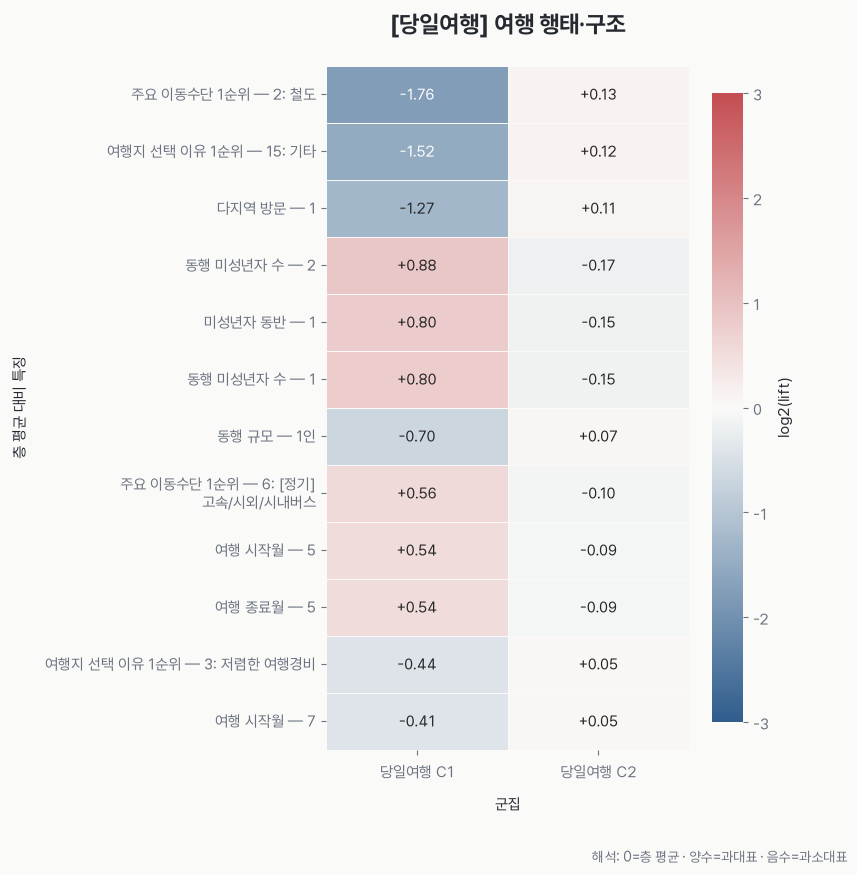

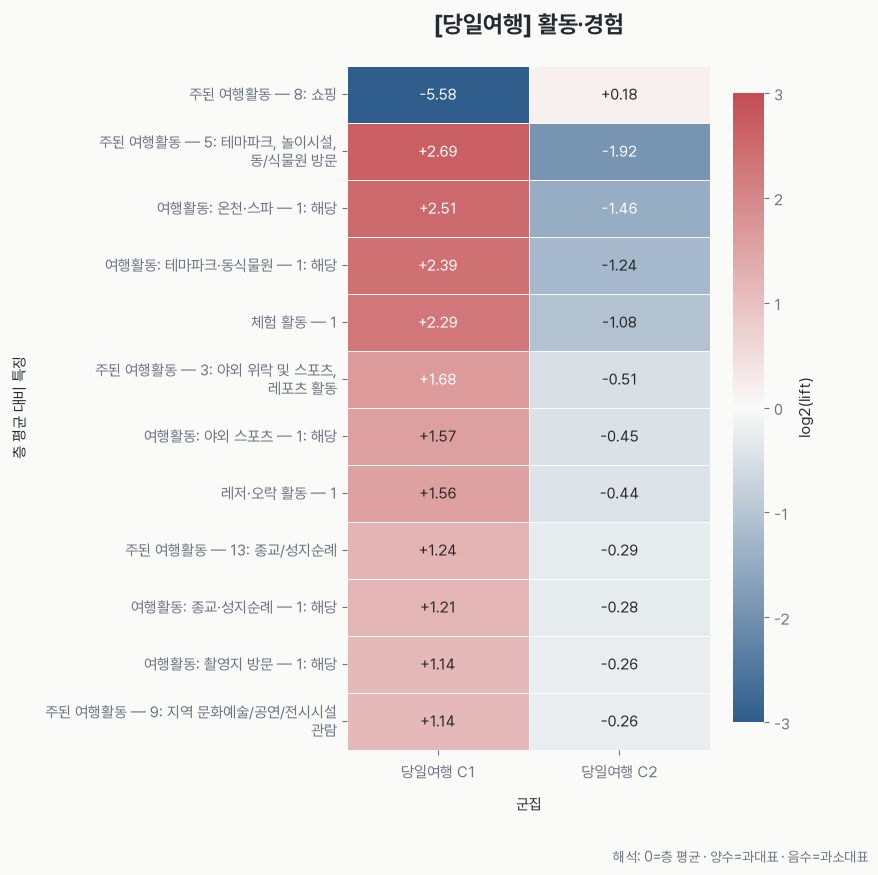

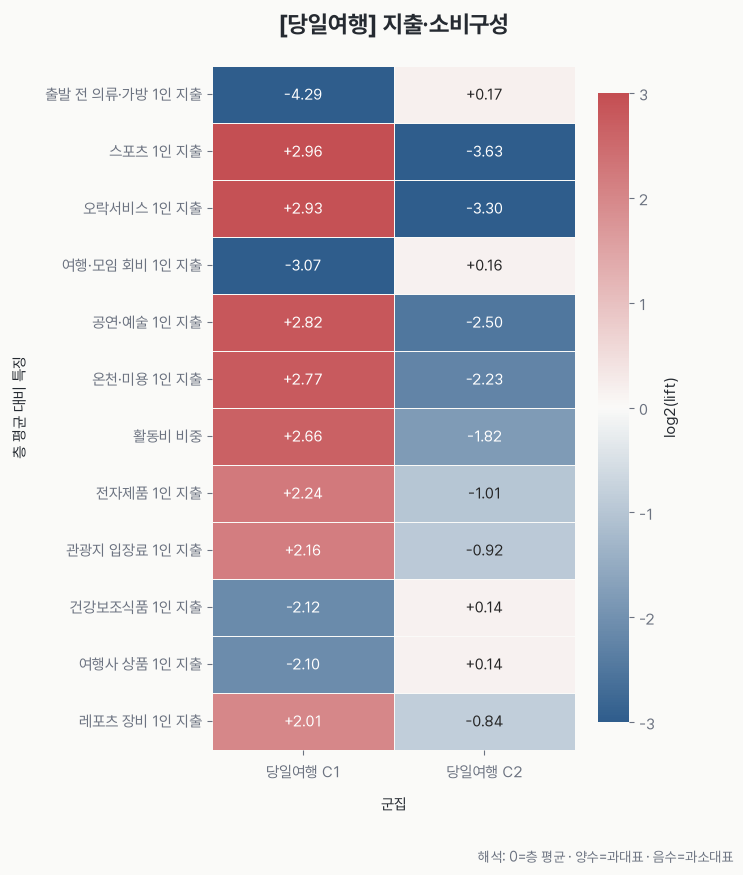

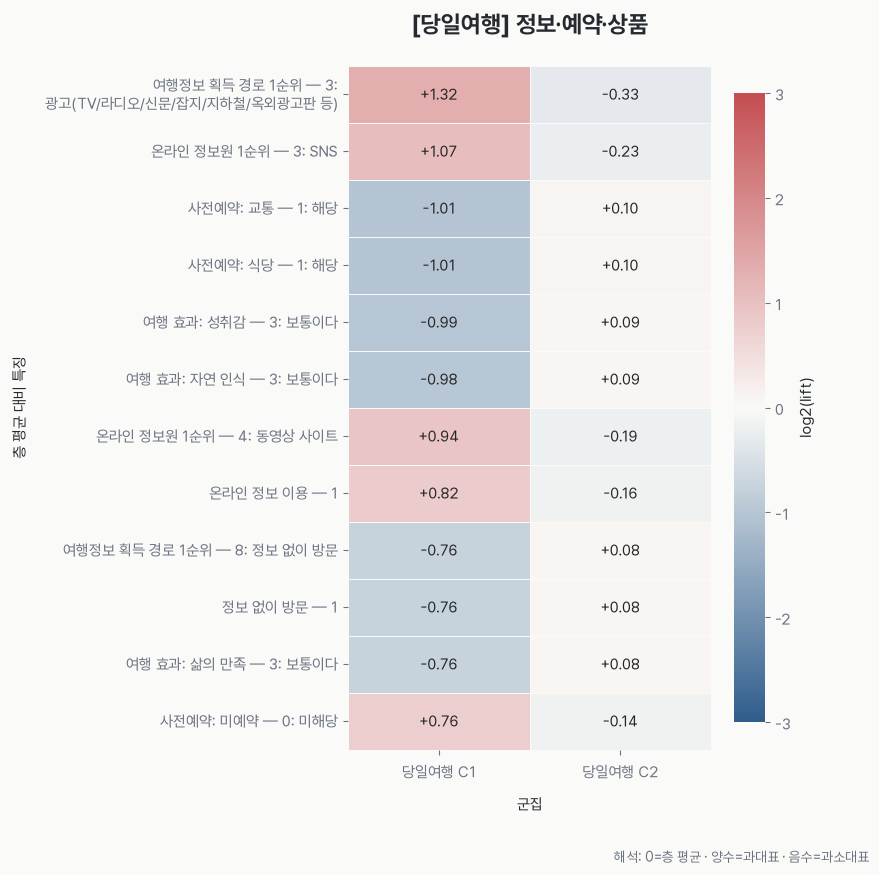

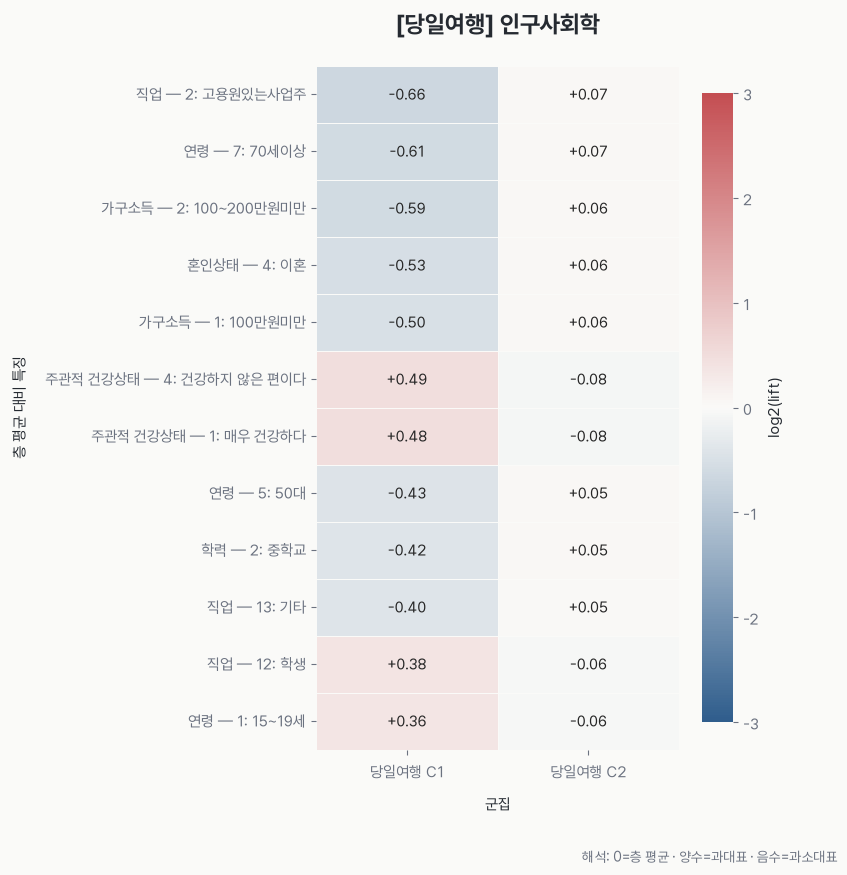

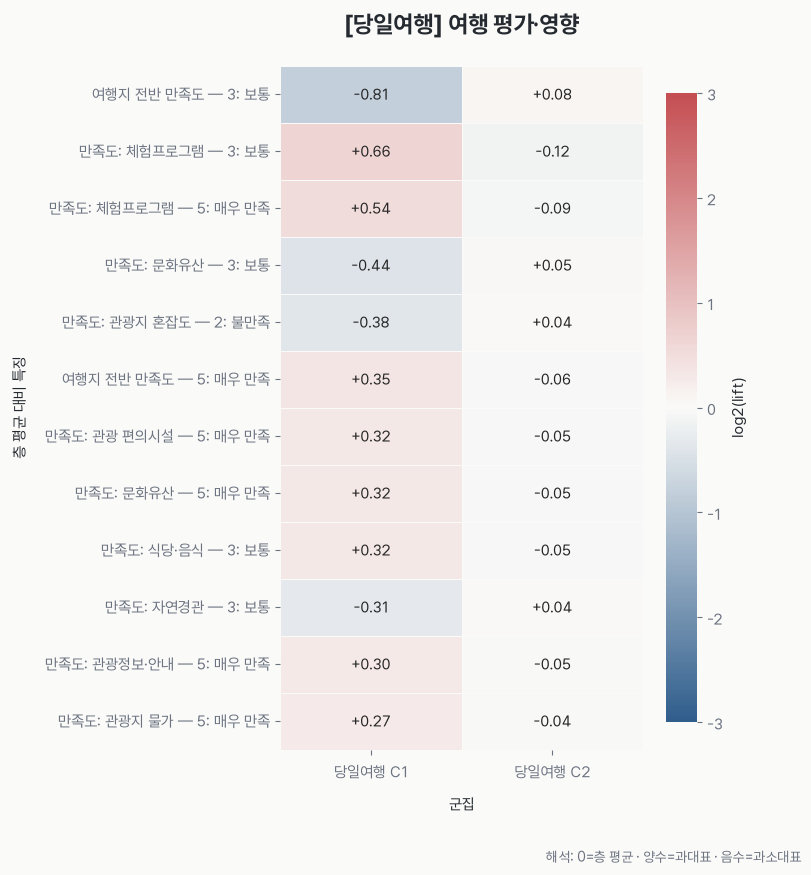

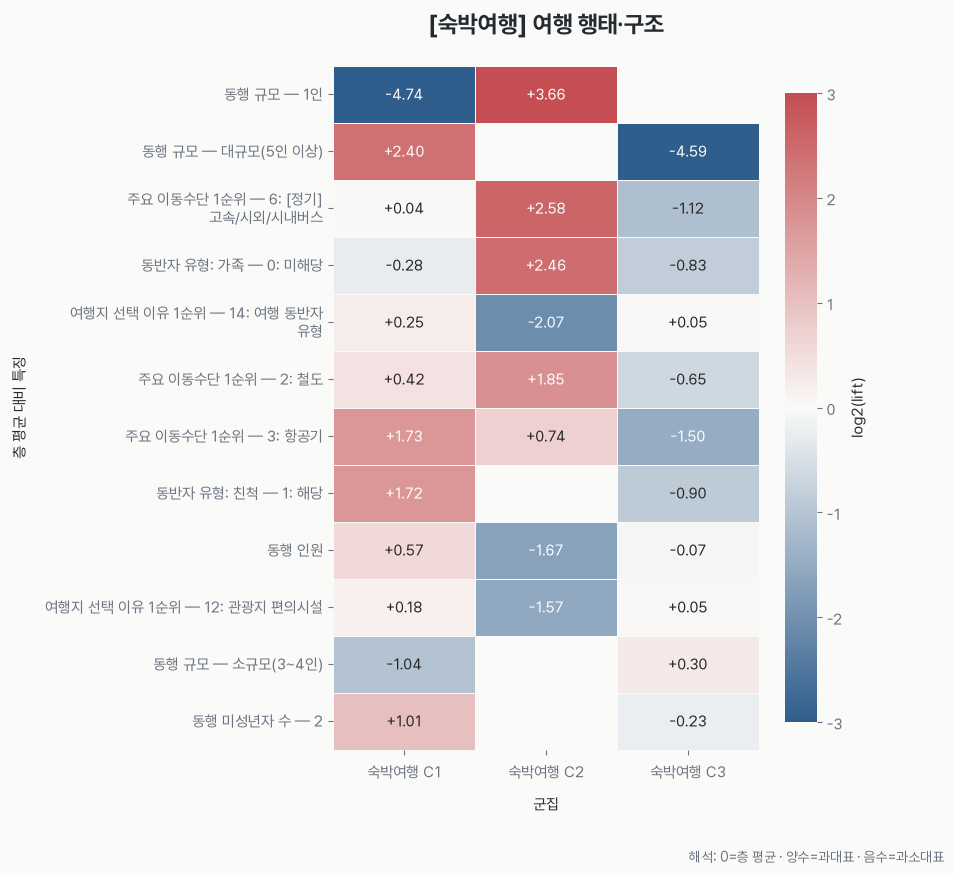

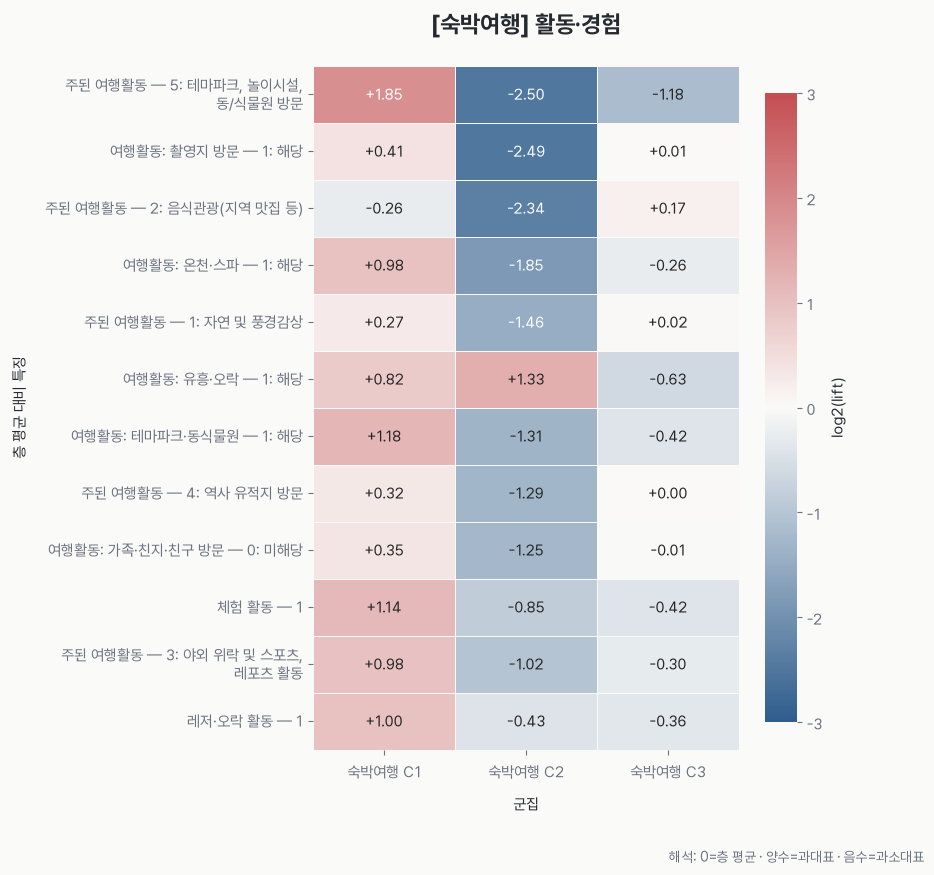

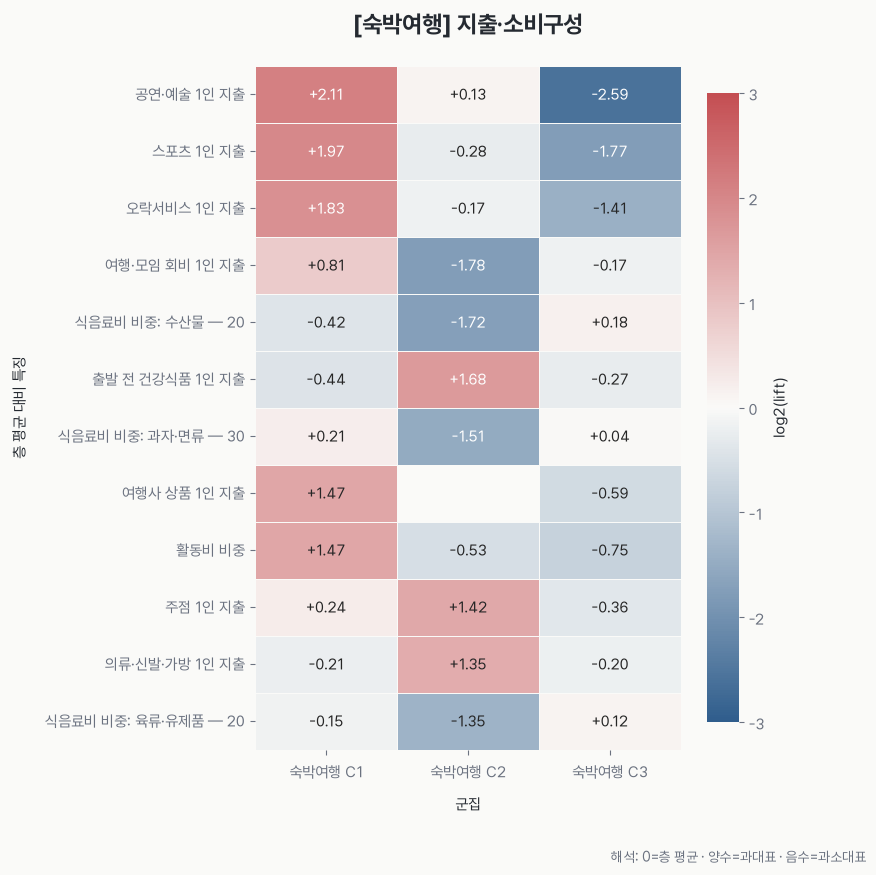

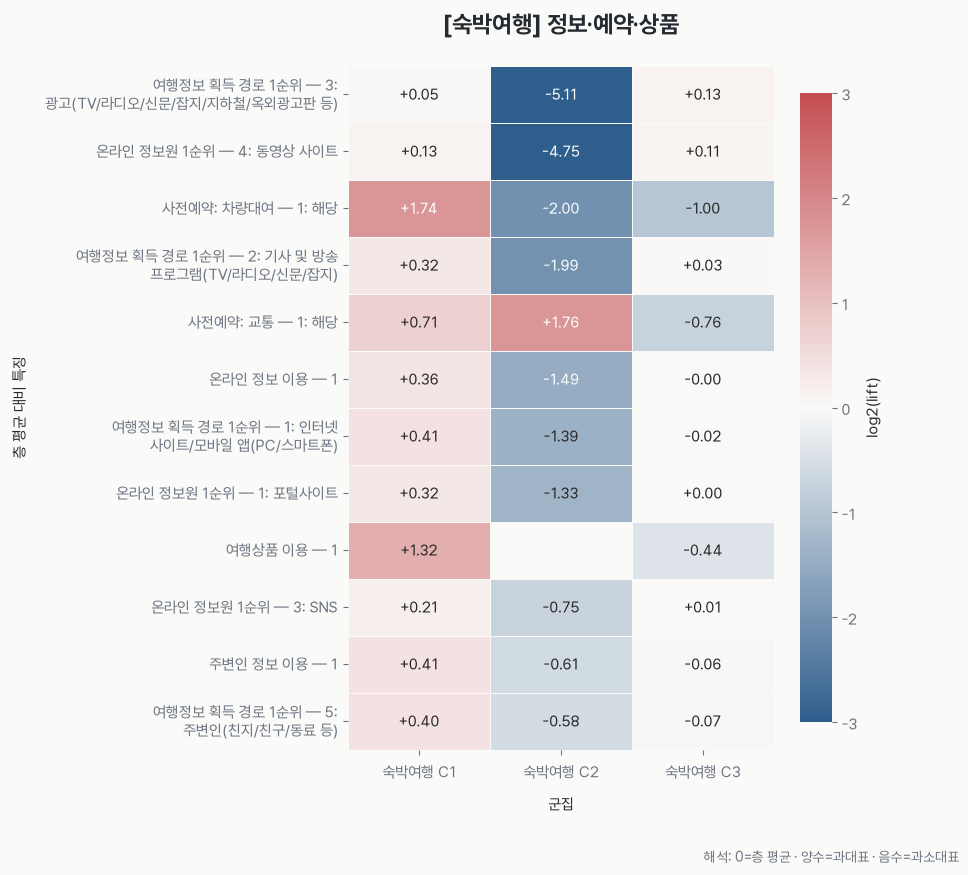

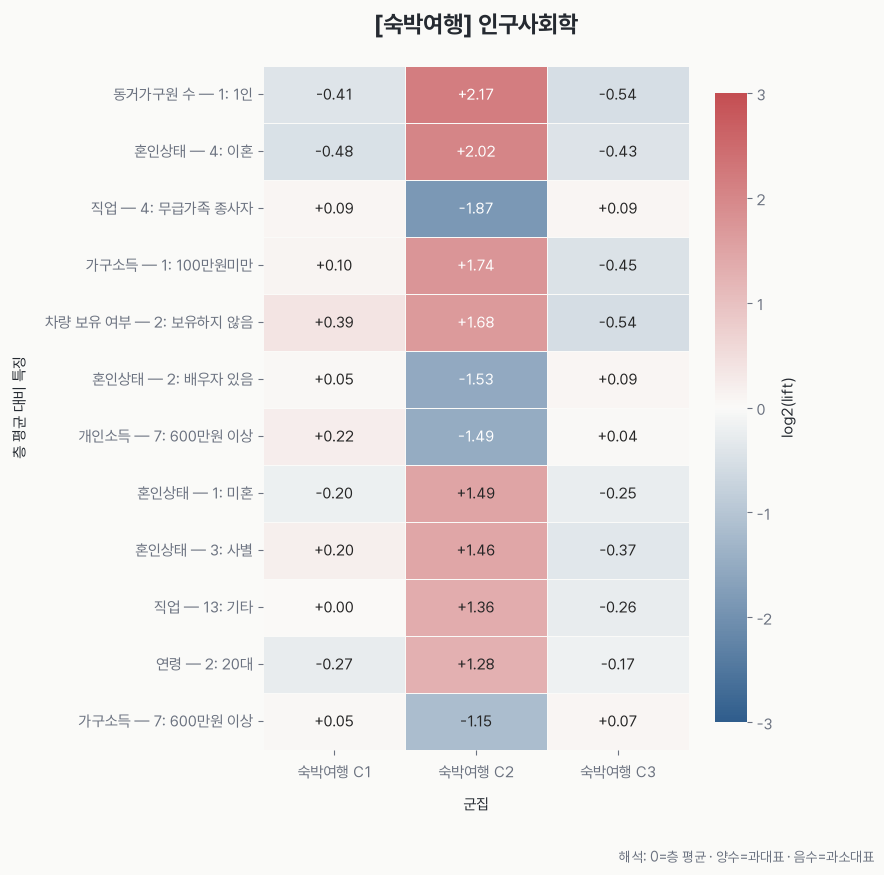

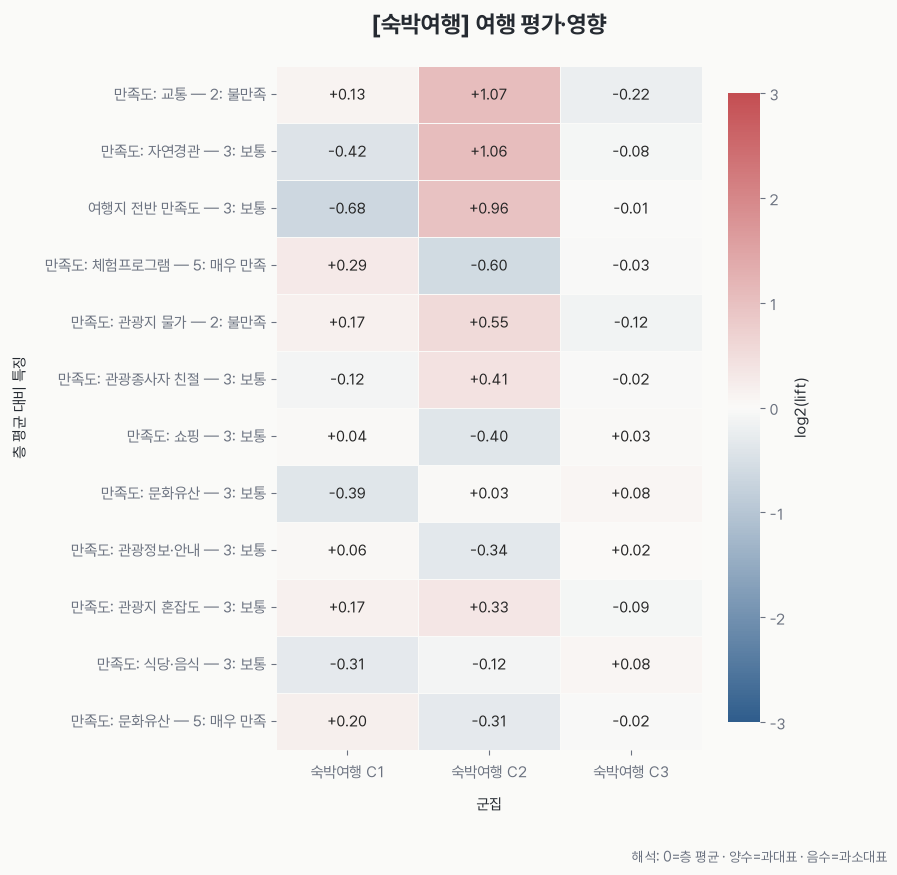

In [5]:
def plot_domain_heatmap(
    frame: pd.DataFrame,
    stratum: str,
    domain: str,
) -> None:
    """한 여행층·도메인의 log2(lift) 히트맵을 저장한다.

    Args:
        frame: 선정된 도메인별 lift 결과.
        stratum: 당일여행 또는 숙박여행 층 이름.
        domain: 시각화할 해석 도메인 이름.
    """
    subset = frame.loc[
        (frame[STRATUM_COLUMN] == stratum)
        & (frame[DOMAIN_COLUMN] == domain)
    ].copy()

    if subset.empty:
        return

    feature_order = (
        subset.assign(_absolute_log2=subset["log2(lift)"].abs())
        .groupby(
            "표시 특징",
            observed=True,
            as_index=False,
        )["_absolute_log2"]
        .max()
        .sort_values(
            ["_absolute_log2", "표시 특징"],
            ascending=[False, True],
        )["표시 특징"]
    )

    heatmap_data = (
        subset.pivot_table(
            index="표시 특징",
            columns=CLUSTER_COLUMN,
            values="log2(lift)",
            aggfunc="first",
        )
        .reindex(feature_order)
    )

    annotations = heatmap_data.map(
        lambda value: "" if pd.isna(value) else f"{value:+.2f}"
    )

    n_features = len(heatmap_data)
    n_clusters = len(heatmap_data.columns)

    # 행과 열 개수에 따라 그림 크기를 유동적으로 조정합니다.
    figure_width = max(7.5, 1.45 * n_clusters + 5.5)
    figure_height = max(4.2, 0.62 * n_features + 1.8)

    figure, axis = plt.subplots(
        figsize=(figure_width, figure_height),
        constrained_layout=False,
    )

    lift_cmap = LinearSegmentedColormap.from_list(
        "domain_log2_lift",
        [
            COLORS["primary"],
            COLORS["background"],
            COLORS["negative"],
        ],
    )

    sns.heatmap(
        heatmap_data,
        cmap=lift_cmap,
        norm=TwoSlopeNorm(
            vmin=-COLOR_LIMIT,
            vcenter=0,
            vmax=COLOR_LIMIT,
        ),
        annot=annotations,
        fmt="",
        linewidths=0.5,
        linecolor=COLORS["background"],
        square=False,
        cbar_kws={
            "label": "log2(lift)",
            "ticks": [-3, -2, -1, 0, 1, 2, 3],
            "shrink": 0.92,
            "pad": 0.05,
        },
        ax=axis,
    )

    # suptitle 대신 축 제목을 사용하면 위치 제어가 더 쉽습니다.
    axis.set_title(
        f"[{stratum}] {domain}",
        fontsize=17,
        fontweight="bold",
        pad=24,
    )

    axis.set_xlabel(
        "군집",
        labelpad=10,
    )
    axis.set_ylabel(
        "층 평균 대비 특징",
        labelpad=12,
    )

    axis.tick_params(
        axis="x",
        rotation=0,
        pad=6,
    )
    axis.tick_params(
        axis="y",
        labelsize=11,
        rotation=0,
        pad=4,
    )

    axis.set_yticklabels(
        [
            fill(
                str(label.get_text()),
                width=FEATURE_LABEL_WRAP_WIDTH,
                break_long_words=False,
                break_on_hyphens=False,
            )
            for label in axis.get_yticklabels()
        ]
    )

    figure.text(
        0.99,
        0.015,
        "해석: 0=층 평균 · 양수=과대표 · 음수=과소대표",
        ha="right",
        va="bottom",
        fontsize=10,
        color=COLORS["neutral"],
    )

    # 긴 y축 라벨을 위한 왼쪽 공간만 확보하고 나머지는 자동 정리합니다.
    figure.subplots_adjust(
        left=0.37,
        right=0.91,
        top=0.88,
        bottom=0.14,
    )

    file_name = (
        f"{stratum}_{domain.replace('·', '_')}"
        "_cluster_lift_heatmap.png"
    )

    figure.savefig(
        FIGURES_DIR / file_name,
        dpi=900,
        bbox_inches="tight",
        pad_inches=0.12,
        facecolor=figure.get_facecolor(),
    )

    plt.show()
    plt.close(figure)


for stratum in domain_summary[STRATUM_COLUMN].unique():
    for domain in DOMAIN_ORDER:
        plot_domain_heatmap(domain_summary, stratum, domain)

## 해석 시 유의점

- 각 그림은 같은 여행층 안에서 도메인별 절대 `log2(lift)`가 큰 특징 최대
  12개를 보여 준다. 한 도메인에서 선택된 특징은 그 층의 모든 군집에 같은
  순서로 제시한다.
- 색 범위는 `-3`부터 `+3`까지로 고정했다. 절대값 3보다 큰 값은 색이
  포화되며, 정확한 값은 셀의 숫자로 확인한다.
- 범주형의 희소 수준은 층 내 가중 비율 1% 이상, 군집 셀 비가중 N 30 이상인
  경우만 후보로 사용했다. `WT_DOM` 가중 lift의 분모와 분석 단위는 기존
  전체변수 lift 분석과 같다.

In [6]:
from src.notebook_sync import sync_script_from_notebook

print("최종 산출물")
for path in sorted(TABLES_DIR.glob("domain_cluster_lift_*.csv")):
    print(f"- 표: {path.name}")
for path in sorted(FIGURES_DIR.glob("*_cluster_lift_heatmap.png")):
    print(f"- 그림: {path.name}")

sync_script_from_notebook(
    "notebooks/04_Clustering/260726_연고관광_도메인별_클러스터_lift.ipynb"
)

최종 산출물
- 표: domain_cluster_lift_selection.csv
- 표: domain_cluster_lift_summary.csv
- 그림: 당일여행_여행 평가_영향_cluster_lift_heatmap.png
- 그림: 당일여행_여행 행태_구조_cluster_lift_heatmap.png
- 그림: 당일여행_인구사회학_cluster_lift_heatmap.png
- 그림: 당일여행_정보_예약_상품_cluster_lift_heatmap.png
- 그림: 당일여행_지출_소비구성_cluster_lift_heatmap.png
- 그림: 당일여행_활동_경험_cluster_lift_heatmap.png
- 그림: 숙박여행_여행 평가_영향_cluster_lift_heatmap.png
- 그림: 숙박여행_여행 행태_구조_cluster_lift_heatmap.png
- 그림: 숙박여행_인구사회학_cluster_lift_heatmap.png
- 그림: 숙박여행_정보_예약_상품_cluster_lift_heatmap.png
- 그림: 숙박여행_지출_소비구성_cluster_lift_heatmap.png
- 그림: 숙박여행_활동_경험_cluster_lift_heatmap.png
생성 스크립트를 노트북 기준으로 만들었습니다: C:\Users\ilove\OneDrive\Desktop\tourism_poster\script\260726_연고관광_도메인별_클러스터_lift.py


WindowsPath('C:/Users/ilove/OneDrive/Desktop/tourism_poster/script/260726_연고관광_도메인별_클러스터_lift.py')